# Assignment 3: Unsupervised Learning — Vancouver Business Licences Explorer

## Setup

Importing the necessary files for this assignment.

In [31]:
# Import core and specialist libraries
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Preprocessing, metrics, clustering, PCA, t-SNE, and UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
import hdbscan
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.utils import resample
import umap

# Configure plotting styles and disable warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Setup complete.")

Setup complete.


## A1 - Data Acquisition & Cleaning

### Exploration: Data Schema
The following table is the first value retrieved from the geojson file. Formatted and explored via mapshaper.org -- command used:

**Console:**
```bash
-info
```

| Field | Value |
|--------|-------|
| businessname | `(Anie Philip)` |
| businesssubtype | |
| businesstradename | |
| businesstype | `Long-term Rental` |
| city | `Vancouver` |
| country | `CA` |
| expireddate | `2025-12-31` |
| extractdate | `2026-07-01T02:32:20-07:00` |
| feepaid | `94` |
| folderyear | `25` |
| geo_point_2d | |
| geom | |
| house | `4959` |
| issueddate | `2024-11-25T21:02:01-08:00` |
| licencenumber | `25-129785` |
| licencerevisionnumber | `00` |
| licencersn | `4637506` |
| localarea | `Renfrew-Collingwood` |
| numberofemployees | `0` |
| postalcode | `V5R 3T5` |
| province | `BC` |
| status | `Inactive` |
| street | `Moss Street` |
| unit | |
| unittype | |

### Cleaning: Creating Data Subset
The parent geojson file is ~140mb, which makes loading and processing difficult when attempting to work with it. I've performed the following operations to shrink 140mb -> 32mb at mapshaper using the following commands:

**First, to drop unnecessary fields (justifications below):**

```bash
-filter-fields businessname,businesstradename,geo_point_2d,localarea,postalcode,businesstype,businesssubtype,status,numberofemployees,feepaid,issueddate,expireddate,licencersn,licencenumber,licencerevisionnumber
```


**Then, drop entries that don't match our conditions:**

```bash
-filter "status == 'Issued' && geo_point_2d != null"
```

### Dropped:

**Fields**:
- `country` & `province` (They are all going to be "CA" and "BC")
- `extractdate` (Just a system download timestamp)
- `folderyear` (Not really relevant for any features)
- `geom` & `house` & `street` & `unit` & `unittype` (we already have geo_point_2d for exact mapping; don't need text addresses)

**Conditions**:
- `status` must be `"Issued"`
- `geo_point_2d` must NOT be `null`


### Cleaning: Updated Data Schema (Example)

| Field | Value |
| :--- | :--- |
| businessname | `Anie Philip` |
| businesssubtype | |
| businesstradename | |
| businesstype | `Long-term Rental` |
| expireddate | `2025-12-31` |
| feepaid | `94` |
| geo_point_2d | `{...}` |
| issueddate | `2024-11-25 (21:02:01 -08:00)` |
| licencenumber | `25-129785` |
| licencersn | `4637506` |
| licenserevisionnumber| `00` |
| localarea | `Renfrew-Collingwood` |
| numberofemployees | `0` |
| postalcode | `V5R 3T5` |
| status | `Inactive` |

In [61]:
# open file "business_locations.geojson"
# load geojson_data using json parser
# print total features count
# print formatted JSON representation of the first feature

with open("data/business-licences-curated-v3.geojson", "r") as file:
    _data = file.read()

# Parse
_data = json.loads(_data)
print(f"Total Features: {len(_data["features"])}")

data = json.dumps(_data, indent=2)
# df = pd.read_json(data). ## This is really slow, idk why

Total Features: 85796


### Cleaning: Convert to Dataframe

In [33]:
rows = []
columns=[
    "businessname",
    "businesssubtype",
    "businesstype",
    "businesstradename",
    "expireddate",
    "feepaid",
    "issueddate",
    "licencenumber",
    "licencerevisionnumber",
    "licencersn",
    "Longitude", 
    "Latitude",   
    "localarea",
    "numberofemployees",
    "postalcode",
    "status"
]
for feat in _data["features"]:
    props = feat["properties"]
    longitude, latitude = feat["geometry"]["coordinates"]
    rows.append({**props, "Longitude": longitude, "Latitude": latitude})
df = pd.DataFrame(rows, columns=columns)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85796 entries, 0 to 85795
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   businessname           85793 non-null  str    
 1   businesssubtype        16200 non-null  str    
 2   businesstype           85796 non-null  str    
 3   businesstradename      42895 non-null  str    
 4   expireddate            85651 non-null  str    
 5   feepaid                59332 non-null  float64
 6   issueddate             85652 non-null  str    
 7   licencenumber          85796 non-null  str    
 8   licencerevisionnumber  85796 non-null  str    
 9   licencersn             85796 non-null  str    
 10  Longitude              85796 non-null  float64
 11  Latitude               85796 non-null  float64
 12  localarea              85796 non-null  str    
 13  numberofemployees      85796 non-null  int64  
 14  postalcode             85142 non-null  str    
 15  status       

In [34]:

print("Average Missing Values Per Column:")
for col in columns:
    print(f"--- {col}: {df[col].isna().mean()}")

Average Missing Values Per Column:
--- businessname: 3.4966665112592664e-05
--- businesssubtype: 0.8111800083919997
--- businesstype: 0.0
--- businesstradename: 0.5000349666651126
--- expireddate: 0.0016900554804419787
--- feepaid: 0.3084526085132174
--- issueddate: 0.0016783999254044479
--- licencenumber: 0.0
--- licencerevisionnumber: 0.0
--- licencersn: 0.0
--- Longitude: 0.0
--- Latitude: 0.0
--- localarea: 0.0
--- numberofemployees: 0.0
--- postalcode: 0.007622732994545201
--- status: 0.0


### Cleaning: Deriving a Fine-Grained Industry Label

`businesstype` is always present, but `businesssubtype` gives a more specific label where it exists (~19% of rows). Combine the two into a single `industry` column: `"businesstype - businesssubtype"` where a subtype exists, falling back to `businesstype` alone otherwise.

In [35]:
df["industry"] = np.where(
    df["businesssubtype"].notna(),
    df["businesstype"] + " - " + df["businesssubtype"],
    df["businesstype"]
)

print(f"Unique businesstype values: {df['businesstype'].nunique()}")
print(f"Unique industry values: {df['industry'].nunique()}")
df[["businesstype", "businesssubtype", "industry"]].sample(10, random_state=RANDOM_STATE)

Unique businesstype values: 90
Unique industry values: 156


,businesstype,businesssubtype,industry
24215,Long-term Rental,NaN,Long-term Rental
72678,Marina Operator,Live Aboard,Marina Operator - Live Aboard
50447,Retail Dealer,NaN,Retail Dealer
67229,Design Services,NaN,Design Services
35073,Laundry Services,NaN,Laundry Services
18215,Health Care Professionals and Services,NaN,Health Care Professionals and Services
12325,Legal Services,NaN,Legal Services
80513,Retail Dealer - Food,NaN,Retail Dealer - Food
53232,Long-term Rental,NaN,Long-term Rental
18278,Health Care Professionals and Services,NaN,Health Care Professionals and Services


### Cleaning: Identifying Duplicates

In [36]:
# Dry run/sanity check of baseline 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85796 entries, 0 to 85795
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   businessname           85793 non-null  str    
 1   businesssubtype        16200 non-null  str    
 2   businesstype           85796 non-null  str    
 3   businesstradename      42895 non-null  str    
 4   expireddate            85651 non-null  str    
 5   feepaid                59332 non-null  float64
 6   issueddate             85652 non-null  str    
 7   licencenumber          85796 non-null  str    
 8   licencerevisionnumber  85796 non-null  str    
 9   licencersn             85796 non-null  str    
 10  Longitude              85796 non-null  float64
 11  Latitude               85796 non-null  float64
 12  localarea              85796 non-null  str    
 13  numberofemployees      85796 non-null  int64  
 14  postalcode             85142 non-null  str    
 15  status       

In [37]:
# Returns a True/False series for every row
duplicate_mask = df.duplicated()

# Filter the DataFrame to see the duplicate entries
duplicate_rows = df[duplicate_mask]

duplicate_rows

,businessname,businesssubtype,businesstype,businesstradename,expireddate,feepaid,issueddate,licencenumber,licencerevisionnumber,licencersn,Longitude,Latitude,localarea,numberofemployees,postalcode,status,industry
79427,IMX PORT TRADING INC.,NaN,Retail Dealer,Ollie & Co.,2026-12-31,634.0,2026-03-31T10:21:25-07:00,26-153897,00,4876481,-123.11973,49.28613,Downtown,1,V6C 1A0,Issued,Retail Dealer


Only one duplicated entry in this row. Nice!

In [38]:
df = df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
Index: 85795 entries, 0 to 85795
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   businessname           85792 non-null  str    
 1   businesssubtype        16200 non-null  str    
 2   businesstype           85795 non-null  str    
 3   businesstradename      42894 non-null  str    
 4   expireddate            85650 non-null  str    
 5   feepaid                59331 non-null  float64
 6   issueddate             85651 non-null  str    
 7   licencenumber          85795 non-null  str    
 8   licencerevisionnumber  85795 non-null  str    
 9   licencersn             85795 non-null  str    
 10  Longitude              85795 non-null  float64
 11  Latitude               85795 non-null  float64
 12  localarea              85795 non-null  str    
 13  numberofemployees      85795 non-null  int64  
 14  postalcode             85141 non-null  str    
 15  status            

### Note - Using LicenseRSN as ID

Referring to the following: https://support.safe.com/hc/en-us/articles/25407521475341-How-to-Prepare-Data-for-Tableau-with-FME-Processing-Spreadsheets<br><br>
> LicenseNumber is an ID number that can be reused and may therefore not be unique. Also, there may be multiple records for the same LicenseNumber; for example, a single business that operates at multiple addresses will have a record in the dataset for each address (but with the same LicenseNumber). LicenseRSN is a unique ID number per license; i.e. each license issued should have a unique LicenseRSN. Of course, there may be multiple records with this value as well, because it should match each record of a multiple LicenseNumber feature.

Following the previously established context, I will be using LicenseRSN as the unique identifier.

## A2: Location-only clustering: K-means vs. DBSCAN

### Initial Scatterplot Look

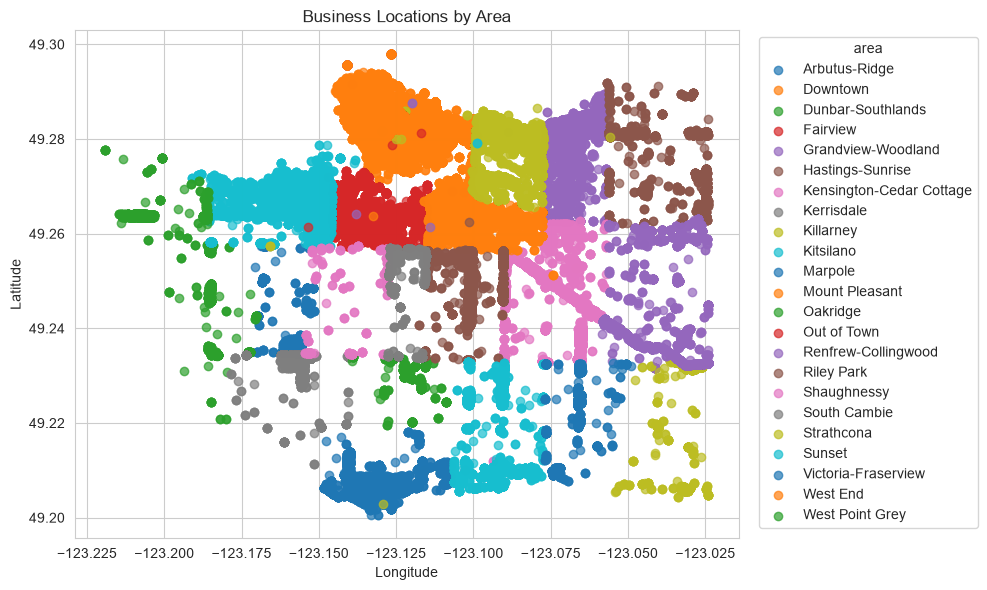

In [39]:
# create scatter plot of Longitude vs Latitude
# group data by Neighborhood and color each group differently
# add labels, legend, and show plot

plt.figure(figsize=(10, 6))
for area, group in df.groupby("localarea"):
    lons = group["Longitude"]
    lats = group["Latitude"]
    plt.scatter(lons, lats, label=area, alpha=0.7)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Business Locations by Area")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="area")
plt.tight_layout()
plt.show()

### Scaling: Geographic Features

In [40]:
geo_features = df[["Longitude", "Latitude"]]
scaler_geo = StandardScaler()
geo_scaled = scaler_geo.fit_transform(geo_features)

print("Before scaling:")
print("Mean:\n", geo_features.mean())
print("Std:\n", geo_features.std())

print("\nAfter scaling:")
print("Mean:", geo_scaled.mean(axis=0))
print("Std:", geo_scaled.std(axis=0))

Before scaling:
Mean:
 Longitude   -123.112167
Latitude      49.265654
dtype: float64
Std:
 Longitude    0.032212
Latitude     0.021541
dtype: float64

After scaling:
Mean: [-9.80718754e-14  2.85512378e-14]
Std: [1. 1.]


### KMeans Clustering

In [41]:
def kmeans_step_by_step(X, k, n_iterations, seed):
    rng = np.random.default_rng(seed)
    initial_idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[initial_idx]
    history = [centroids.copy()]

    labels = None
    for _ in range(n_iterations):
        distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
            for i in range(k)
        ])
        centroids = new_centroids
        history.append(centroids.copy())

    return history, labels

centroid_history, final_labels = kmeans_step_by_step(geo_scaled, k=4, n_iterations=5, seed=RANDOM_STATE)
print(len(centroid_history))

6


### Graphing KMeans Clusters

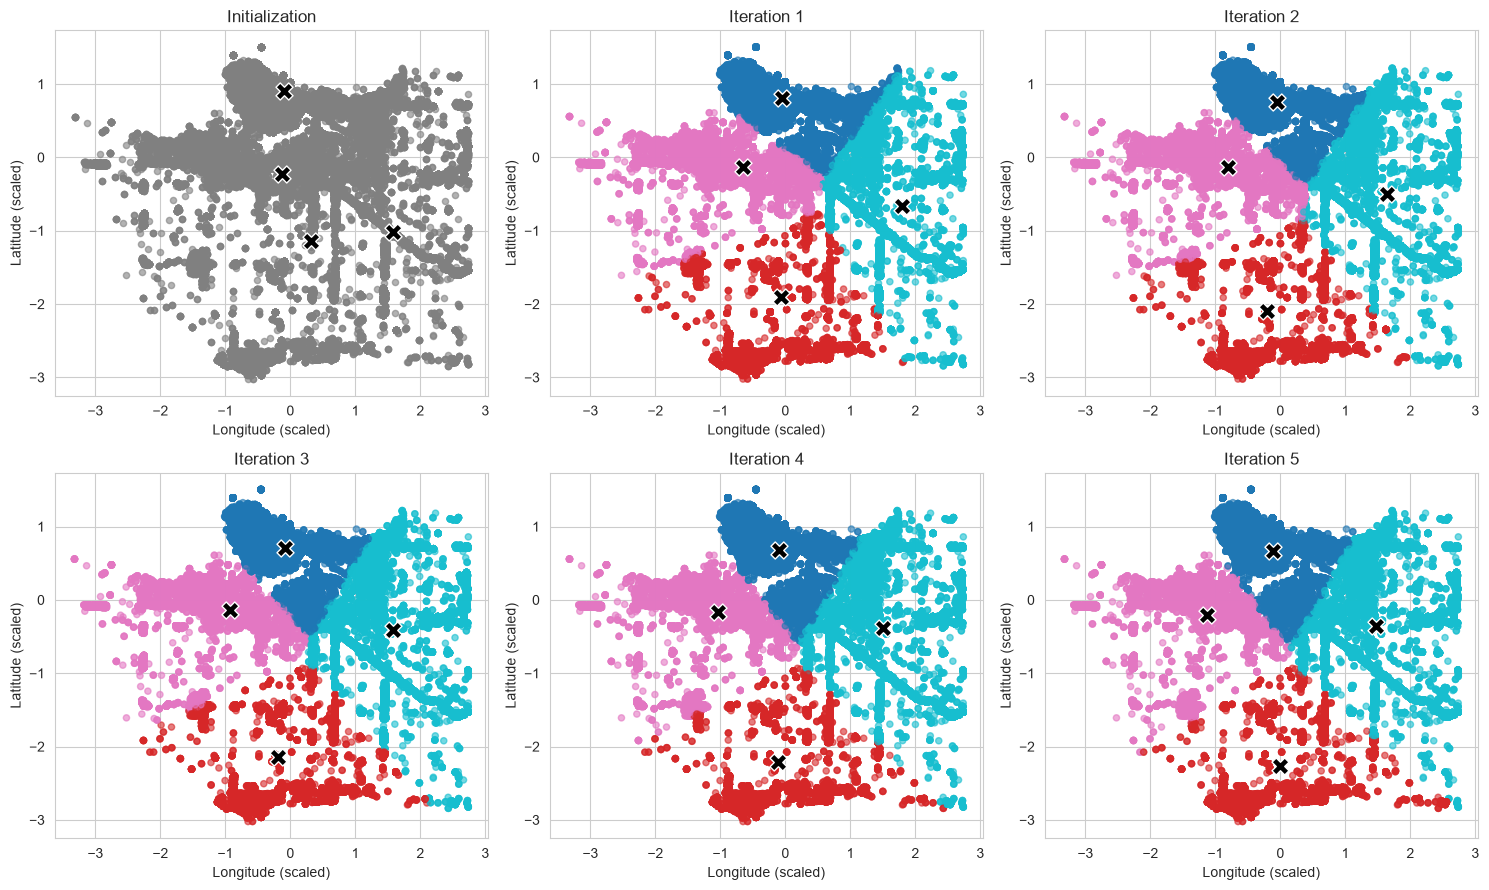

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    centroids = centroid_history[i]

    if i == 0:
        ax.scatter(geo_scaled[:, 0], geo_scaled[:, 1], c="gray", alpha=0.6, s=20)
        ax.set_title("Initialization")
    else:
        distances = np.linalg.norm(geo_scaled[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        labels = np.argmin(distances, axis=1)
        ax.scatter(geo_scaled[:, 0], geo_scaled[:, 1], c=labels, cmap="tab10", alpha=0.6, s=20)
        ax.set_title(f"Iteration {i}")

    ax.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=150, edgecolor="white")
    ax.set_xlabel("Longitude (scaled)")
    ax.set_ylabel("Latitude (scaled)")

plt.tight_layout()
plt.show()

### Elbow Method & Silhouette Score

I took a 20% sample size for silhouette score to help speed up the process.

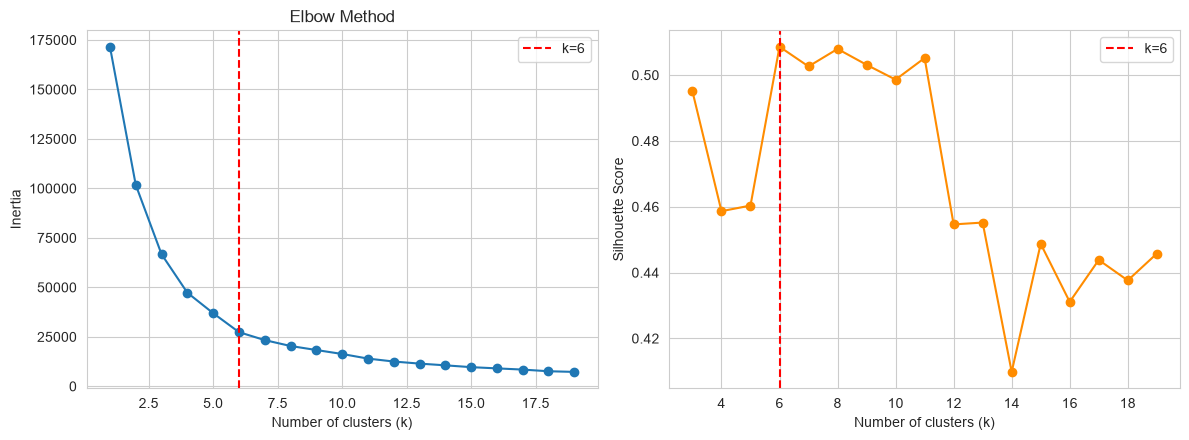

In [43]:
inertias = []
k_max = 20
for k in range(1, k_max):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(geo_scaled)
    inertias.append(km.inertia_)


# Sample 20% of the dataset
X_subset = resample(geo_scaled, n_samples=int(0.2 * len(geo_scaled)), random_state=42)

silhouette_scores = {}
for k in range(3, k_max):
    km = KMeans(n_clusters = k, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(X_subset)
    silhouette_scores[k] = silhouette_score(X_subset, km_labels)


fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(range(1, k_max), inertias, marker="o")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow Method")
ax[0].axvline(x=6, color="red", linestyle="--", label="k=6")
ax[0].legend()

ax[1].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="darkorange")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].axvline(x=6, color="red", linestyle="--", label="k=6")
ax[1].legend()

plt.tight_layout()
plt.show()


Looking at the graphs, I identify k=6 as the optimal cluster number.

#### Plotting KMeans with Optimal K

Here, I plot KMeans again with the optimal cluster number of k=6

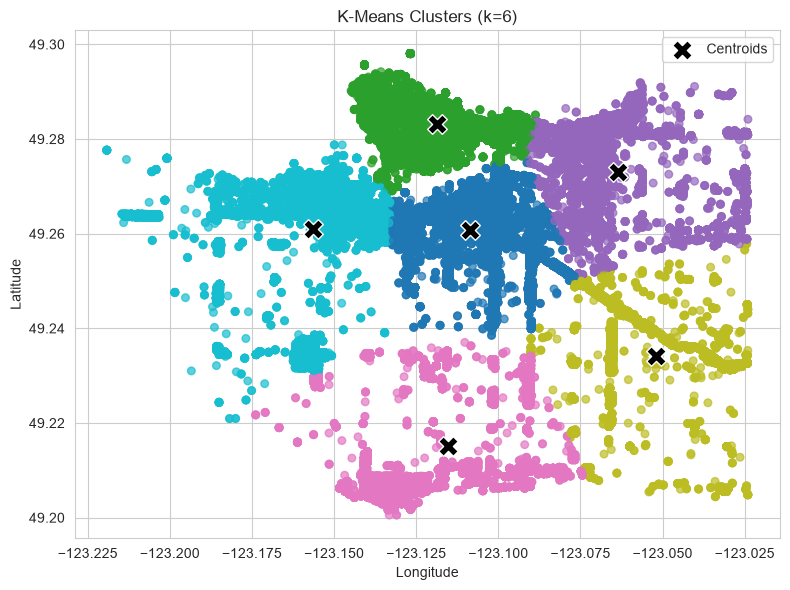

In [44]:
kmeans_final = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10)
df["KMeans_Cluster"] = kmeans_final.fit_predict(geo_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["Longitude"], df["Latitude"], c=df["KMeans_Cluster"], cmap="tab10", alpha=0.7, s=30)

centroids_geo = scaler_geo.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_geo[:, 0], centroids_geo[:, 1], c="black", marker="X", s=200, edgecolor="white", label="Centroids")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clusters (k=6)")
plt.legend()
plt.tight_layout()
plt.show()

### Evaluating: DBSCAN

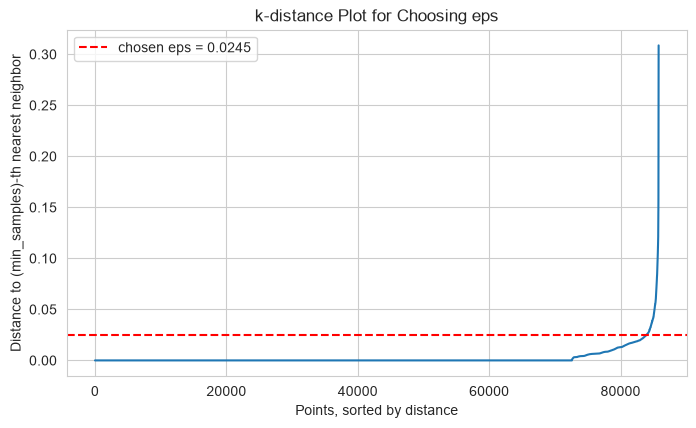

In [45]:
min_samples = 4

neighbours_model = NearestNeighbors(n_neighbors=min_samples)
neighbours_model.fit(geo_scaled)
distances, _ = neighbours_model.kneighbors(geo_scaled)

k_distances = np.sort_complex(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot (k_distances)
ax.axhline(0.0245, color="red", linestyle="--", label="chosen eps = 0.0245")
ax.set_xlabel("Points, sorted by distance")
ax.set_ylabel(f"Distance to (min_samples)-th nearest neighbor")
ax.set_title("k-distance Plot for Choosing eps")
ax.legend() 
plt.show()

In [46]:
dbscan = DBSCAN(eps=0.0245, min_samples=4)
df["DBSCAN_Cluster"] = dbscan.fit_predict(geo_scaled)

n_clusters_dbscan = len(set(df["DBSCAN_Cluster"])) - (1 if -1 in df["DBSCAN_Cluster"].values else 0)

n_noise_dbscan = (df["DBSCAN_Cluster"] == -1).sum()
print(f"Number of clusters: {n_clusters_dbscan} and number of noise points: {n_noise_dbscan}")

Number of clusters: 1167 and number of noise points: 1922


I observe that my chosen parameters yields the following: Number of clusters: 1167 and number of noise points: 1922. I find these numbers & results to be surprising but also suspicious. Going forward, I will investigate why there is such a large discrepancy between the results yielded by KMeans and DBSCAN.

### Investigating the Cluster-Count Discrepancy

As mentioned earlier, I argue that 1167 clusters is suspiciously high compared to the KMeans result of k=6, so I decided it's worth digging into why before trusting either number. KMeans always returns exactly k clusters by construction (it's not looking for density, it's minimizing variance), so the two counts were never guaranteed to agree. But 1167 clusters and 1922 noise points still seems too fragmented for a city-wide business dataset, so I decided to check for a concrete data issue: duplicate coordinates.

Many businesses (in malls, office towers, and other multi-tenant buildings) share the exact same `geo_point_2d`. If a large fraction of rows are literal duplicates, most points' distance to their `min_samples`-th nearest neighbor will be ~0, which drags the k-distance elbow down to a tiny `eps` that only bridges duplicates within the same building — too small to bridge to the building next door.

In [47]:
coord_counts = df.groupby(["Longitude", "Latitude"]).size()

print(f"Total rows: {len(df)}")
print(f"Unique (Longitude, Latitude) pairs: {len(coord_counts)}")
print(f"Rows sharing a coordinate with at least one other row: {coord_counts[coord_counts > 1].sum()}")

print("\nMost duplicated locations:")
print(coord_counts.sort_values(ascending=False).head())

Total rows: 85795
Unique (Longitude, Latitude) pairs: 8725
Rows sharing a coordinate with at least one other row: 85227

Most duplicated locations:
Longitude    Latitude 
-123.118825  49.263938    596
-123.118287  49.285718    537
-123.117751  49.283401    505
-123.121464  49.285245    485
-123.117898  49.281832    482
dtype: int64


After de-duplicating the locations, I observe that 85,795 rows collapse to just 8,725 unique locations. Moreover, 99% (85227 out of 85795) of rows share their coordinate with another row, and the busiest single address has nearly 600 businesses registered at it. It's also worth noting that because I dropped the fields containing business names, 

This confirms the hypothesis: the original `eps=0.0245` was tuned almost entirely by these duplicate stacks, not by the spacing between distinct addresses.

Let's de-duplicate down to one row per unique coordinate and redo the k-distance plot on that — this shows the real spacing between distinct business locations, uncontaminated by the duplicate stacks.

De-duplicated from 85795 rows down to 8725 unique locations


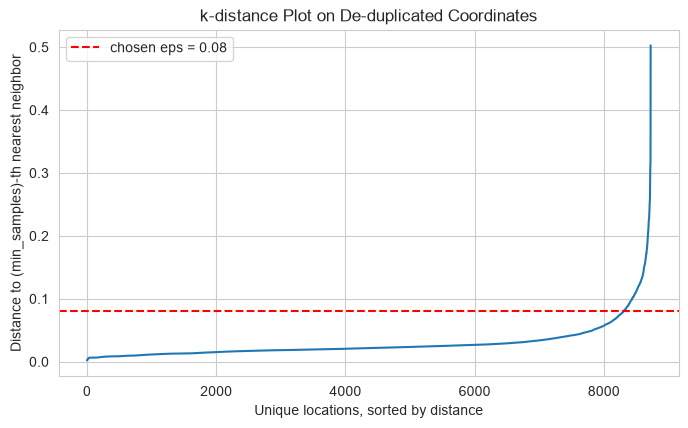

In [48]:
geo_unique = df[["Longitude", "Latitude"]].drop_duplicates().to_numpy()
geo_unique_scaled = scaler_geo.transform(geo_unique)

print(f"De-duplicated from {len(df)} rows down to {len(geo_unique)} unique locations")

neighbours_model_dedup = NearestNeighbors(n_neighbors=min_samples)
neighbours_model_dedup.fit(geo_unique_scaled)
distances_dedup, _ = neighbours_model_dedup.kneighbors(geo_unique_scaled)

k_distances_dedup = np.sort(distances_dedup[:, -1])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_distances_dedup)
ax.axhline(0.08, color="red", linestyle="--", label="chosen eps = 0.08")
ax.set_xlabel("Unique locations, sorted by distance")
ax.set_ylabel(f"Distance to (min_samples)-th nearest neighbor")
ax.set_title("k-distance Plot on De-duplicated Coordinates")
ax.legend()
plt.show()

Once the duplicate stacks are removed, the elbow sits much further out — around `eps=0.08` instead of `0.0245` — reflecting the real spacing between distinct addresses rather than the near-zero spacing between businesses sharing a building. Refit DBSCAN on the de-duplicated locations with this larger `eps`, then map each unique location's label back onto every row that shares its coordinate.

In [49]:
dbscan_dedup = DBSCAN(eps=0.08, min_samples=min_samples)
dedup_labels = dbscan_dedup.fit_predict(geo_unique_scaled)

dedup_lookup = pd.DataFrame(geo_unique, columns=["Longitude", "Latitude"])
dedup_lookup["DBSCAN_Cluster_v2"] = dedup_labels

df = df.merge(dedup_lookup, on=["Longitude", "Latitude"], how="left")

n_clusters_v2 = len(set(dedup_labels)) - (1 if -1 in dedup_labels else 0)
n_noise_v2 = (df["DBSCAN_Cluster_v2"] == -1).sum()
print(f"Number of clusters: {n_clusters_v2} and number of noise points: {n_noise_v2} (out of {len(df)} rows)")

Number of clusters: 55 and number of noise points: 1377 (out of 85795 rows)


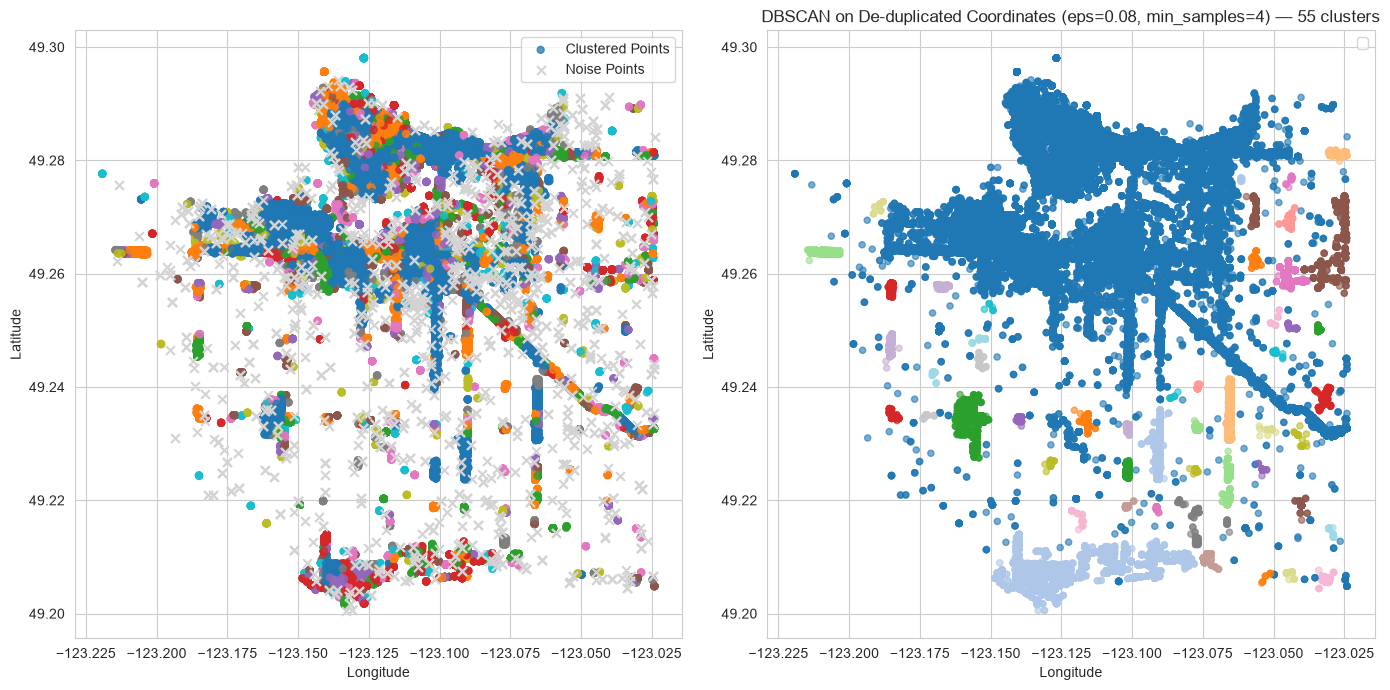

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(14,7))

noise_mask = df["DBSCAN_Cluster"] == -1
ax[0].scatter(
    df.loc[~noise_mask, "Longitude"], 
    df.loc[~noise_mask, "Latitude"], 
    c = df.loc[~noise_mask, "DBSCAN_Cluster"], 
    cmap="tab10", 
    s=25, 
    alpha=0.75, 
    label="Clustered Points"
)
ax[0].scatter(
    df.loc[noise_mask, "Longitude"], 
    df.loc[noise_mask, "Latitude"], 
    c = "lightgrey", 
    marker="x",
    s=40,
    label="Noise Points"
)
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].legend()


ax[1].scatter(
    df["Longitude"], 
    df["Latitude"], 
    c=df["DBSCAN_Cluster_v2"], 
    cmap="tab20", 
    alpha=0.6, 
    s=20)

ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")
ax[1].set_title(f"DBSCAN on De-duplicated Coordinates (eps=0.08, min_samples={min_samples}) — {n_clusters_v2} clusters")
ax[1].legend()
plt.tight_layout()
plt.show()

This gives ~55 clusters and only ~1,400 noise points (1.6% of rows) — a much more plausible result than the original 1167 clusters / 1922 noise points, and much closer with the ~22 official Vancouver local areas/neighbourhoods (https://en.wikipedia.org/wiki/List_of_neighbourhoods_in_Vancouver) split into finer, distinct commercial nodes. 

### Markdown Answers

1. How do the K-means clusters map onto actual Vancouver geography — do they correspond to anything you'd recognize (downtown core, west side, etc.)?

The K-means clusters maps well onto actual Vancouver geography. I identified 6 main districts by using the elbow-method, which maps to generally "Downtown", "West-side (Kits/West-point Grey)", "Granville "Fairview/mount pleasant", "East-side (Strathcona/Granview)", "south-side "Marpole", and "south-east side "kensington/Renfrew". 


2. How do the DBSCAN clusters compare? Where do the two methods agree or disagree, and why — think about what each algorithm assumes about cluster shape and density, and what DBSCAN's "noise" points represent.

The K-means clusters on the deduplicated DBSCAN resolves to 55 clusters. Just from looking at the maps, I find it interesting that the business tend to cluster around busy roads. For example, when I overlaid the diagonal blue cluster that tails off the east end of the DBSCAN map, I found that it maps onto Kingsway -- which is a popular commercial district in Burnaby, with many businesses. However, this is quite different from what I observed via KMeans. Yet, I argue this is to be expected because these two algorithms answer different questions. KMeans was forced to summarize the whole city into exactly 6 broad geographic partitions, while DBSCAN (once the duplicate-coordinate artifact is removed) is free to reveal however many genuinely dense business districts actually exist at a given spatial resolution — which is naturally a much finer-grained number than "6".

## A3: Feature-based clustering: Size, Industry, Lifecycle

### Engineering Features

This section moves away from geography and clusters businesses on three attribute groups instead:

- **Size** — `numberofemployees` and `feepaid`
- **Industry** — the consolidated `industry` label built in A1 (`businesstype` + `businesssubtype`), encoded
- **Lifecycle** — licence duration (`expireddate - issueddate`), the month the licence was issued (cyclically encoded), and `licencerevisionnumber`

I'll build each group separately, scale everything onto a comparable footing, then combine into one feature matrix for K-means.

### Lifecycle Features

`issueddate` and `expireddate` are both parsed as dates so I can derive:
- `licence_duration_days` = `expireddate - issueddate`
- `month_issued_sin` / `month_issued_cos` — the calendar month a licence was issued, cyclically encoded so December and January stay close together instead of 11 apart
- `licence_revision_number` — `licencerevisionnumber` cast to an integer (it's zero-padded text in the source data, e.g. `"00"`, `"01"`, `"10"`)

A small number of rows (~0.2%) are missing `issueddate`/`expireddate` entirely and get dropped.

In [51]:
n_before = len(df)

df["issueddate_dt"] = pd.to_datetime(df["issueddate"], utc=True, errors="coerce")
df["expireddate_dt"] = pd.to_datetime(df["expireddate"], utc=True, errors="coerce")
df = df.dropna(subset=["issueddate_dt", "expireddate_dt"]).copy()

print(f"Dropped {n_before - len(df)} rows missing issueddate/expireddate")

df["licence_duration_days"] = (df["expireddate_dt"] - df["issueddate_dt"]).dt.days

month_issued = df["issueddate_dt"].dt.month
df["month_issued_sin"] = np.sin(2 * np.pi * month_issued / 12)
df["month_issued_cos"] = np.cos(2 * np.pi * month_issued / 12)

df["licence_revision_number"] = df["licencerevisionnumber"].astype(int)

df["licence_duration_days"].describe()

Dropped 145 rows missing issueddate/expireddate


count    85650.000000
mean       350.331909
std         81.313304
min       -354.000000
25%        345.000000
50%        377.000000
75%        399.000000
max        601.000000
Name: licence_duration_days, dtype: float64

A small number of rows (66, ~0.08%) come out with a *negative* duration — the licence's `expireddate` falls before its `issueddate`. This looks like a data-entry quirk around renewals (e.g. a licence renewed late, where the new `issueddate` is stamped after the old `expireddate` it's replacing) rather than a real business attribute, so these rows are dropped.

In [52]:
n_before = len(df)
df = df[df["licence_duration_days"] >= 0].copy()
print(f"Dropped {n_before - len(df)} rows with a negative licence duration")
print(f"Remaining rows: {len(df)}")

Dropped 66 rows with a negative licence duration
Remaining rows: 85584


### Size Features

`numberofemployees` and `feepaid` are both heavily right-skewed (a handful of businesses report thousands of employees or tens of thousands in fees), so I log-transform both (`log1p`, which handles the `numberofemployees == 0` case) before scaling.

`feepaid` is also missing on ~31% of rows. Rather than guess at *why* a fee wasn't recorded, I impute the missing values with the column median and add a `fee_missing` flag so K-means can still separate "actually cheap" from "unknown fee" if that turns out to matter.

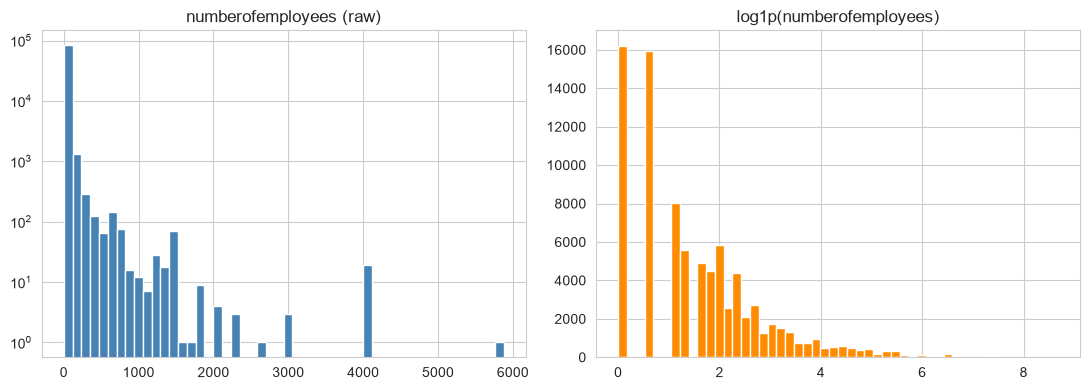

,numberofemployees,feepaid_imputed,log_employees,log_feepaid,fee_missing
count,85584.000000,85584.000000,85584.000000,85584.000000,85584.000000
mean,18.031022,541.532648,1.565459,5.773236,0.308913
std,103.353251,1274.723873,1.308556,0.920995,0.462048
min,0.000000,2.000000,0.000000,1.098612,0.000000
25%,1.000000,277.000000,0.693147,5.627621,0.000000
50%,3.000000,277.000000,1.386294,5.627621,0.000000
75%,9.000000,331.000000,2.302585,5.805135,1.000000
max,5876.000000,63722.000000,8.678802,11.062301,1.000000


In [53]:
df["fee_missing"] = df["feepaid"].isna().astype(int)
df["feepaid_imputed"] = df["feepaid"].fillna(df["feepaid"].median())

df["log_employees"] = np.log1p(df["numberofemployees"])
df["log_feepaid"] = np.log1p(df["feepaid_imputed"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["numberofemployees"], bins=50, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_title("numberofemployees (raw)")
axes[1].hist(df["log_employees"], bins=50, color="darkorange")
axes[1].set_title("log1p(numberofemployees)")
plt.tight_layout()
plt.show()

df[["numberofemployees", "feepaid_imputed", "log_employees", "log_feepaid", "fee_missing"]].describe()

### Industry Feature

The `industry` column from A1 (`businesstype` + `businesssubtype` where a subtype exists) has 156 unique values, and one-hot encoding all of them would let industry dominate the distance metric relative to the handful of size/lifecycle columns, while also giving K-means 156 mostly-empty, high-cardinality dimensions to fit noise on.

Instead, I keep the 20 most common `industry` values as their own categories and collapse everything else into `"Other"`, then one-hot encode that consolidated column (21 dimensions total).

In [54]:
TOP_N_INDUSTRIES = 20

top_industries = df["industry"].value_counts().nlargest(TOP_N_INDUSTRIES).index
df["industry_consolidated"] = np.where(df["industry"].isin(top_industries), df["industry"], "Other")

industry_dummies = pd.get_dummies(df["industry_consolidated"], prefix="industry").astype(float)

print(f"Consolidated {df['industry'].nunique()} industry values down to {df['industry_consolidated'].nunique()} categories")
df["industry_consolidated"].value_counts()

Consolidated 151 industry values down to 21 categories


industry_consolidated
Other                                                  22655
Health Care Professionals and Services                 11771
Long-term Rental                                        9392
Retail Dealer                                           6007
Legal Services                                          5199
Restaurant - Class 1 with liquor service                3334
Business Support Services                               2957
Financial Services                                      2398
Consulting and Management Services                      2351
Limited Service Food Establishment - Without Liquor     2343
Real Estate Services                                    2049
Retail Dealer - Food                                    1935
General Contractor                                      1785
Information Communication Technology                    1702
Association or Society                                  1611
Restaurant - Class 1 no liquor service                  1503
Wh

### Combining & Scaling the Feature Set

I then apply `StandardScaler` to the continuous numeric columns (`log_employees`, `log_feepaid`, `licence_duration_days`, `licence_revision_number`) so none of them dominates purely because of its raw units. The cyclical month features (`month_issued_sin/cos`) are already bounded to `[-1, 1]` and the industry/`fee_missing` columns are already binary 0/1, so both are left as-is — scaling them further would only distort the meaning of "same category" vs. "different category."

In [55]:
continuous_cols = ["log_employees", "log_feepaid", "licence_duration_days", "licence_revision_number"]

scaler_features = StandardScaler()
continuous_scaled = pd.DataFrame(
    scaler_features.fit_transform(df[continuous_cols]),
    columns=continuous_cols,
    index=df.index,
)

feature_matrix = pd.concat(
    [continuous_scaled, df[["month_issued_sin", "month_issued_cos", "fee_missing"]], industry_dummies.set_axis(df.index)],
    axis=1,
)

X_features = feature_matrix.to_numpy()
print(f"Feature matrix shape: {feature_matrix.shape}")
feature_matrix.head()

Feature matrix shape: (85584, 28)


,log_employees,log_feepaid,licence_duration_days,licence_revision_number,month_issued_sin,month_issued_cos,fee_missing,industry_Association or Society,industry_Beauty Services - Barber Shop or Beauty Salon,industry_Beauty Services - Beauty and Wellness Centre,...,industry_Limited Service Food Establishment,industry_Limited Service Food Establishment - Without Liquor,industry_Long-term Rental,industry_Other,industry_Real Estate Services,industry_Restaurant - Class 1 no liquor service,industry_Restaurant - Class 1 with liquor service,industry_Retail Dealer,industry_Retail Dealer - Food,industry_Wholesale Dealer - Non-Food
0,-1.196332,-0.378165,0.699333,-0.683942,-0.500000,0.866025,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.196332,-0.165946,0.699333,-0.683942,-0.500000,0.866025,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.196332,-0.577085,0.004594,-0.683942,0.500000,0.866025,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.196332,0.335490,-0.342775,-0.683942,0.866025,0.500000,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.196332,-0.138752,0.612490,-0.683942,-0.500000,0.866025,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


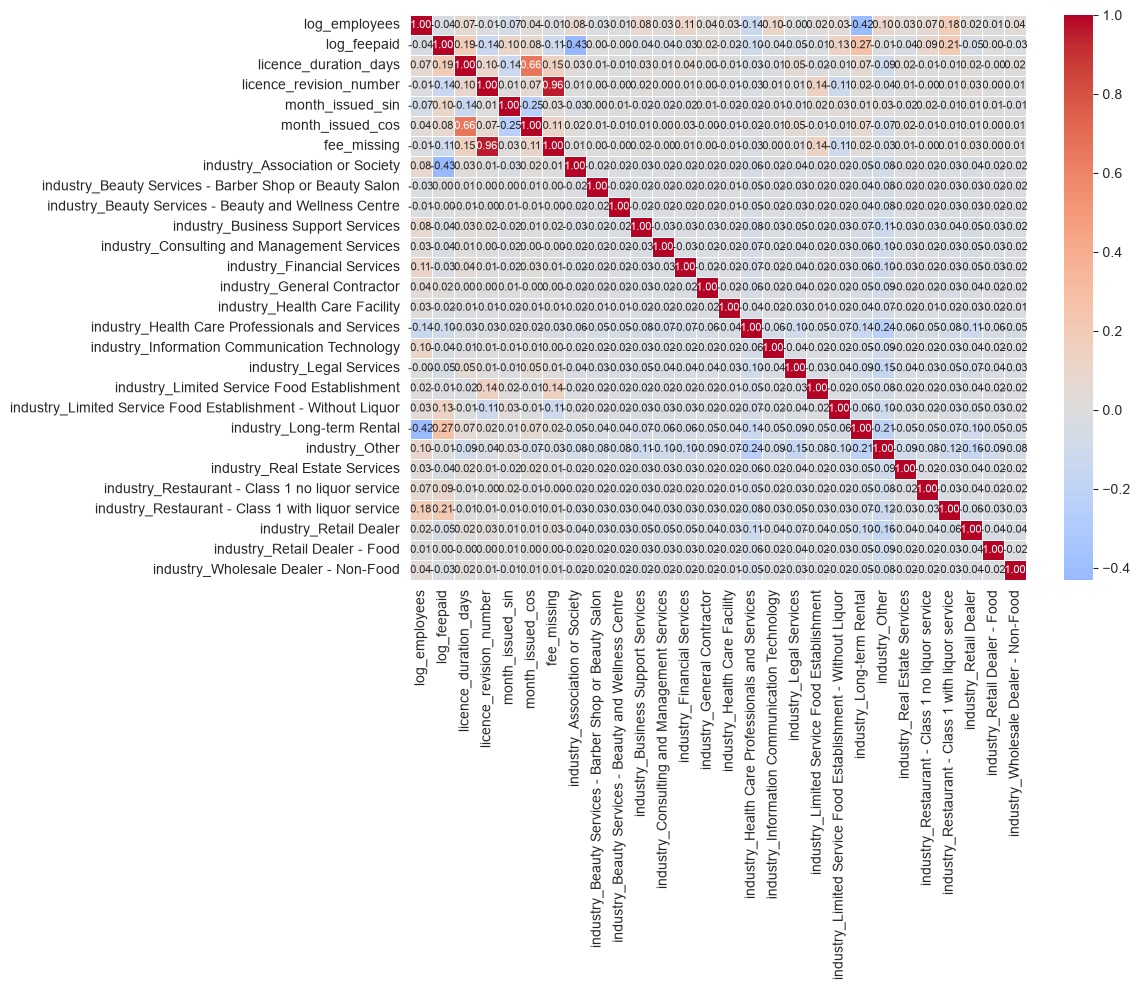

In [56]:
numeric_features = feature_matrix.select_dtypes(include='number').columns.tolist()
corr = feature_matrix[numeric_features].corr()

# Plot as heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8}
)
plt.tight_layout()
plt.show()

### K-means Clustering

Here, I'll be using the same approach as A2: an elbow plot over inertia, plus a silhouette score computed on a 20% sample for speed.

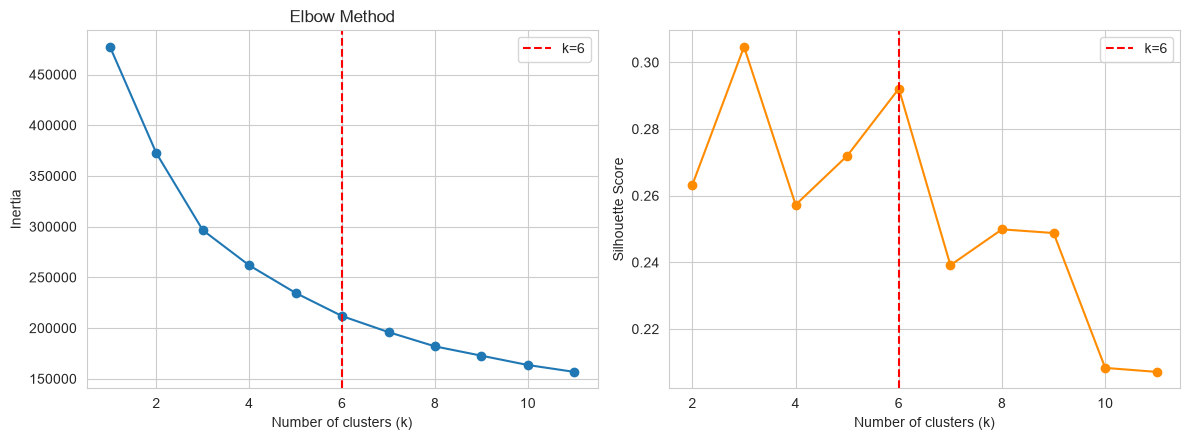

In [57]:
k_max = 12

inertias = []
for k in range(1, k_max):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_features)
    inertias.append(km.inertia_)

X_features_subset = resample(X_features, n_samples=int(0.2 * len(X_features)), random_state=RANDOM_STATE)
silhouette_scores = {}
for k in range(2, k_max):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(X_features_subset)
    silhouette_scores[k] = silhouette_score(X_features_subset, km_labels)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(range(1, k_max), inertias, marker="o")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow Method")
ax[0].axvline(x=6, color="red", linestyle="--", label="k=6")
ax[0].legend()

ax[1].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="darkorange")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].axvline(x=6, color="red", linestyle="--", label="k=6")
ax[1].legend()

plt.tight_layout()
plt.show()

The elbow is gradual rather than sharp — expected, since a mix of continuous and one-hot features rarely produces the clean knee a single spatial feature pair does. Silhouette peaks slightly at k=3 (0.30) but k=6 (0.29) is a close second and, when I inspect cluster means, k=3 barely separates on size/lifecycle (employees ~15-20, duration ~370-375 days across all three groups) while k=6 splits out clearly distinct profiles — e.g. one cluster of large employers (~100 employees), one of short-duration licences (~140 days), and one of high-fee licences (~$2,900). I'll go with **k=6**, trading a marginally lower silhouette score for clusters that are actually interpretable, and it keeps this section comparable to the k=6 chosen for location in A2.

In [58]:
kmeans_features_final = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10)
df["Feature_Cluster"] = kmeans_features_final.fit_predict(X_features)

df["Feature_Cluster"].value_counts().sort_index()

Feature_Cluster
0     6878
1     1687
2    33036
3    24809
4    11015
5     8159
Name: count, dtype: int64

#### Cluster Profiles

A quick sanity check on what each cluster actually represents, before projecting to 2D.

In [59]:
profile = df.groupby("Feature_Cluster")[["numberofemployees", "feepaid_imputed", "licence_duration_days"]].mean()
profile["top_industry"] = df.groupby("Feature_Cluster")["industry_consolidated"].agg(lambda s: s.value_counts().idxmax())
profile["n_businesses"] = df.groupby("Feature_Cluster").size()
profile

,numberofemployees,feepaid_imputed,licence_duration_days,top_industry,n_businesses
Feature_Cluster,,,,,
0,5.549142,2919.889309,359.804304,Long-term Rental,6878
1,21.780083,13.709544,349.512152,Association or Society,1687
2,2.943244,333.135573,374.442124,Other,33036
3,6.687049,277.158128,372.780201,Other,24809
4,101.712846,565.809714,380.040218,Other,11015
5,10.388283,260.635699,139.650815,Other,8159


### PCA Projection to 2D

The feature matrix has 28 dimensions (4 scaled numeric + 2 cyclical + `fee_missing` + 21 industry dummies), too many to plot directly. PCA compresses it down to the 2 directions of greatest variance so the clusters can be visualized on a scatter plot.

Explained variance ratio: PC1=0.233, PC2=0.228
Total variance captured: 0.461


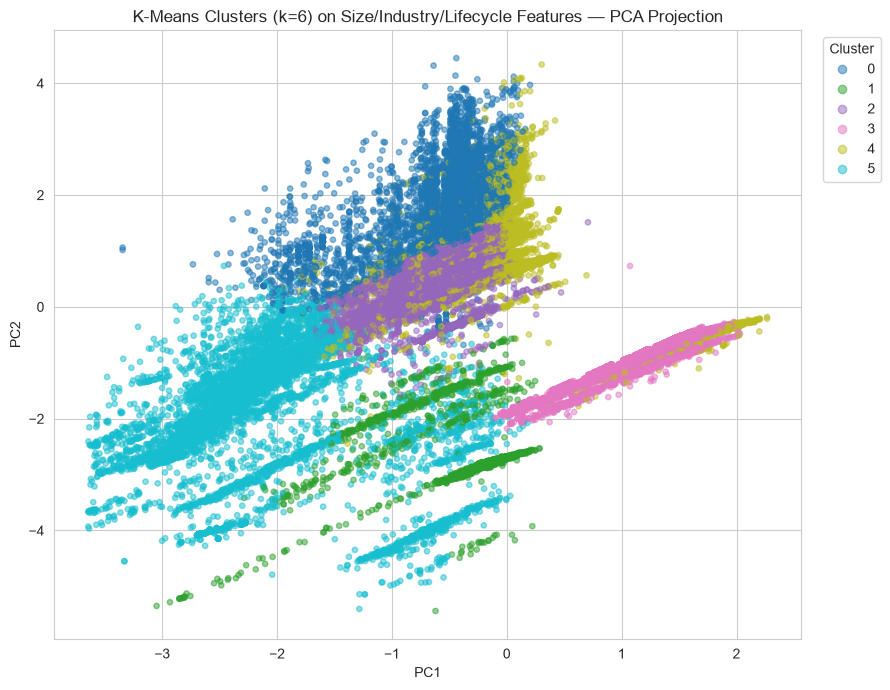

In [60]:
pca_features = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_features.fit_transform(X_features)

print(f"Explained variance ratio: PC1={pca_features.explained_variance_ratio_[0]:.3f}, PC2={pca_features.explained_variance_ratio_[1]:.3f}")
print(f"Total variance captured: {pca_features.explained_variance_ratio_.sum():.3f}")

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Feature_Cluster"], cmap="tab10", alpha=0.5, s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (k=6) on Size/Industry/Lifecycle Features — PCA Projection")
plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Questions Answered

1. What do the resulting clusters seem to represent? Does this differ from the purely geographic clustering in A2?

The two components capture ~46% of total variance — I argue this is a reasonable amount given the feature set mixes continuous lifecycle/size signals with a wide, sparse block of industry dummies (which individually contribute very little variance each). The dominant loadings on PC1/PC2 are `licence_revision_number` and `licence_duration_days`, so this 2D view is mostly a "lifecycle" projection: it separates clusters by how long a licence has been active and how many times it's been revised, more than by industry or size. That lines up with the cluster profile table above, where the clearest cross-cluster differences were in `licence_duration_days` (~140 vs. ~370-380 days) rather than in employees or fees. Compared to simply geographic clustering as done in A2, this clustering shows more behavioural patterns within the businesses themselves.